=============================================================
###  ANALYSE GDELT — BÉNIN INSIGHTS
###  iSHEERO × DataCamp Hackathon 2026
==============================================================


### OBJECTIFs :

**1. Surveiller les activités politiques et Sécuritaires au Bénin**

**2. Analyser l'image du Bénin dans les médias mondiaux**

**3. Détecter les évenements à haute sensibilité**

### 01- Importation des librairies

In [23]:
import pandas as pd
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import seaborn as sns
from IPython.display import Image, display
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (classification_report, confusion_matrix,
                              ConfusionMatrixDisplay, accuracy_score, roc_auc_score)
from sklearn.inspection import permutation_importance
import warnings
warnings.filterwarnings("ignore")

**Style global des graphiques**

In [2]:
import os
plt.rcParams.update({
    "figure.facecolor"  : "#FAFAFA",
    "axes.facecolor"    : "#FFFFFF",
    "axes.grid"         : True,
    "grid.alpha"        : 0.35,
    "grid.linestyle"    : "--",
    "font.family"       : "DejaVu Sans",
    "axes.spines.top"   : False,
    "axes.spines.right" : False,
    "axes.titlesize"    : 13,
    "axes.labelsize"    : 11,
})

# Palette
BLEU    = "#1D4ED8"
VERT    = "#16A34A"
ROUGE   = "#DC2626"
ORANGE  = "#D97706"
VIOLET  = "#7C3AED"
CYAN    = "#0891B2"

# Couleurs pour QuadClass (1=cooperation verbale, 2=cooperation matérielle, 3=conflit verbal, 4=conflit matérielle)
QUAD_COULEURS = {1: VERT, 2: CYAN, 3: ORANGE, 4: ROUGE}
QUAD_LABELS   = {
    1: "Coopération verbale",
    2: "Coopération matérielle",
    3: "Conflit verbal",
    4: "Conflit matériel"
}

OUTPUT = os.makedirs("visual_graphique", exist_ok=True)


### 02- Chargement des données

In [4]:
df = pd.read_csv('../data/raw/gdelt_benin_2025_clean.csv')
df.head()

,GlobalEventID,SQLDATE,MonthYear,Year,FractionDate,Actor1Code,Actor1Name,Actor1CountryCode,Actor1Type1Code,Actor2Code,...,ActionGeo_CountryCode,ActionGeo_ADM1Code,ActionGeo_Lat,ActionGeo_Long,ActionGeo_FeatureID,DATEADDED,SOURCEURL,mois,mois_nom,semaine
0,1218370051,2025-01-01,202501,2025,2025.0027,BEN,BENIN,BEN,NaN,NaN,...,BN,BN,9.5,2.25,BN,20250101003000,https://punchng.com/pdp-seeks-igs-intervention...,1,January,1
1,1218370053,2025-01-01,202501,2025,2025.0027,BEN,BENIN,BEN,NaN,NER,...,BN,BN,9.5,2.25,BN,20250101003000,https://guardian.ng/news/benin-protests-remark...,1,January,1
2,1218370054,2025-01-01,202501,2025,2025.0027,BEN,BENINESE,BEN,NaN,NER,...,BN,BN,9.5,2.25,BN,20250101003000,https://guardian.ng/news/benin-protests-remark...,1,January,1
3,1218370056,2025-01-01,202501,2025,2025.0027,BEN,BENIN,BEN,NaN,NERGOV,...,BN,BN,9.5,2.25,BN,20250101003000,https://guardian.ng/news/benin-protests-remark...,1,January,1
4,1218370058,2025-01-01,202501,2025,2025.0027,BENGOV,BENINESE,BEN,GOV,NER,...,BN,BN,9.5,2.25,BN,20250101003000,https://guardian.ng/news/benin-protests-remark...,1,January,1


### 03- Exploratory Analysis Data (EDA)

**Analyses descriptives**

In [5]:
# analysis descriptives

describe_analysis = df.describe(exclude='object')
print(describe_analysis)

       GlobalEventID      MonthYear     Year  FractionDate   IsRootEvent  \
count   1.904200e+04   19042.000000  19042.0  19042.000000  19042.000000   
mean    1.252831e+09  202506.960403   2025.0   2025.529332      0.618738   
std     1.933336e+07       3.702120      0.0      0.302850      0.485710   
min     1.218370e+09  202501.000000   2025.0   2025.002700      0.000000   
25%     1.236708e+09  202504.000000   2025.0   2025.268500      0.000000   
50%     1.252805e+09  202507.000000   2025.0   2025.542500      1.000000   
75%     1.271907e+09  202511.000000   2025.0   2025.824700      1.000000   
max     1.281700e+09  202512.000000   2025.0   2025.989000      1.000000   

          EventCode  EventBaseCode  EventRootCode     QuadClass  \
count  19042.000000   19042.000000   19042.000000  19042.000000   
mean      96.577618      69.552673       6.788520      1.791251   
std      186.027772      55.642545       5.560848      1.141509   
min       10.000000      10.000000       1.0000

**data types**

In [6]:
df.dtypes

GlobalEventID              int64
SQLDATE                      str
MonthYear                  int64
Year                       int64
FractionDate             float64
Actor1Code                   str
Actor1Name                   str
Actor1CountryCode            str
Actor1Type1Code              str
Actor2Code                   str
Actor2Name                   str
Actor2CountryCode            str
Actor2Type1Code              str
IsRootEvent                int64
EventCode                  int64
EventBaseCode              int64
EventRootCode              int64
QuadClass                  int64
GoldsteinScale           float64
NumMentions                int64
NumSources                 int64
NumArticles                int64
AvgTone                  float64
Actor1Geo_Type             int64
Actor1Geo_FullName           str
Actor1Geo_CountryCode        str
Actor1Geo_ADM1Code           str
Actor1Geo_ADM2Code           str
Actor1Geo_Lat            float64
Actor1Geo_Long           float64
Actor1Geo_

In [7]:
print("Shape:", df.shape)
print("\nColonnes:", list(df.columns))
print("\n--- Valeurs uniques clés ---")
for col in ["Actor1CountryCode","Actor2CountryCode","ActionGeo_CountryCode","QuadClass","EventRootCode","Year"]:
    if col in df.columns:
        print(f"{col}: {df[col].value_counts().head(8).to_dict()}")

# Numériques
for col in ["GoldsteinScale","AvgTone","NumMentions","NumSources","NumArticles"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")
    print(f"{col}: min={df[col].min():.2f}, max={df[col].max():.2f}, mean={df[col].mean():.2f}, null={df[col].isna().sum()}")

print("\nSQLDATE range:", df["SQLDATE"].min(), "→", df["SQLDATE"].max())
print("\nTop Actor1Name:", df["Actor1Name"].value_counts().head(10).to_dict())
print("\nTop Actor2Name:", df["Actor2Name"].value_counts().head(8).to_dict())
print("\nTop ActionGeo_FullName:", df["ActionGeo_FullName"].value_counts().head(10).to_dict())
print("\nMissing values (%):\n", (df.isnull().mean()*100).round(1).sort_values(ascending=False).head(20))

Shape: (19042, 51)

Colonnes: ['GlobalEventID', 'SQLDATE', 'MonthYear', 'Year', 'FractionDate', 'Actor1Code', 'Actor1Name', 'Actor1CountryCode', 'Actor1Type1Code', 'Actor2Code', 'Actor2Name', 'Actor2CountryCode', 'Actor2Type1Code', 'IsRootEvent', 'EventCode', 'EventBaseCode', 'EventRootCode', 'QuadClass', 'GoldsteinScale', 'NumMentions', 'NumSources', 'NumArticles', 'AvgTone', 'Actor1Geo_Type', 'Actor1Geo_FullName', 'Actor1Geo_CountryCode', 'Actor1Geo_ADM1Code', 'Actor1Geo_ADM2Code', 'Actor1Geo_Lat', 'Actor1Geo_Long', 'Actor1Geo_FeatureID', 'Actor2Geo_Type', 'Actor2Geo_FullName', 'Actor2Geo_CountryCode', 'Actor2Geo_ADM1Code', 'Actor2Geo_ADM2Code', 'Actor2Geo_Lat', 'Actor2Geo_Long', 'Actor2Geo_FeatureID', 'ActionGeo_Type', 'ActionGeo_FullName', 'ActionGeo_CountryCode', 'ActionGeo_ADM1Code', 'ActionGeo_Lat', 'ActionGeo_Long', 'ActionGeo_FeatureID', 'DATEADDED', 'SOURCEURL', 'mois', 'mois_nom', 'semaine']

--- Valeurs uniques clés ---
Actor1CountryCode: {'BEN': 5217, 'NGA': 2135, 'AFR': 4

In [9]:
# Conversion de la date (gestion du format détecté dans l'erreur précédente)
df['SQLDATE'] = pd.to_datetime(df['SQLDATE'])
df['month_year'] = df['SQLDATE'].dt.to_period('M').astype(str)

# Variables dérivées
# Ces colonnes synthétisent de l'information pour faciliter l'analyse
df["is_conflict"]     = df["QuadClass"].isin([3, 4]).astype(int)
df["is_cooperation"]  = df["QuadClass"].isin([1, 2]).astype(int)
df["QuadClass_label"] = df["QuadClass"].map(QUAD_LABELS)

# Intensité médiatique = pondération de la couverture presse
df["media_intensity"] = (
    df["NumMentions"].fillna(0) +
    df["NumSources"].fillna(0) * 2 +
    df["NumArticles"].fillna(0) * 1.5
)

# Signalement d'un problème qualité important
# "BENIN CITY" est une ville du Nigeria, pas du Bénin.
# Elle apparaît dans Actor1Name/Actor2Name car GDELT extrait le
# texte brut des articles sans toujours différencier les entités.
# On le documente — les journalistes doivent en être informés.
nb_benin_city = (df["Actor1Name"] == "BENIN CITY").sum() + \
                (df["Actor2Name"] == "BENIN CITY").sum()

print(f"\n {len(df):,} événements chargés")
print(f" Conflits  : {df['is_conflict'].sum():,} ({df['is_conflict'].mean()*100:.1f}%)")
print(f" Coopération.   : {df['is_cooperation'].sum():,} ({df['is_cooperation'].mean()*100:.1f}%)")
print(f" Goldstein : {df['GoldsteinScale'].mean():+.2f} (neutre = 0)")
print(f" Ton méd.  : {df['AvgTone'].mean():+.2f} (neutre = 0)")
print(f"\n Problème qualité détecté : 'BENIN CITY' (ville du Nigeria)")
print(f" apparaît {nb_benin_city:,} fois dans les acteurs → à interpréter avec précaution")


 19,042 événements chargés
 Conflits  : 5,189 (27.3%)
 Coopération.   : 13,853 (72.7%)
 Goldstein : +0.41 (neutre = 0)
 Ton méd.  : -1.67 (neutre = 0)

 Problème qualité détecté : 'BENIN CITY' (ville du Nigeria)
 apparaît 915 fois dans les acteurs → à interpréter avec précaution


### VISUALISATION 1 : ÉVOLUTION TEMPORELLE DES ÉVÉNEMENTS



 Évolution temporelle mensuelle...


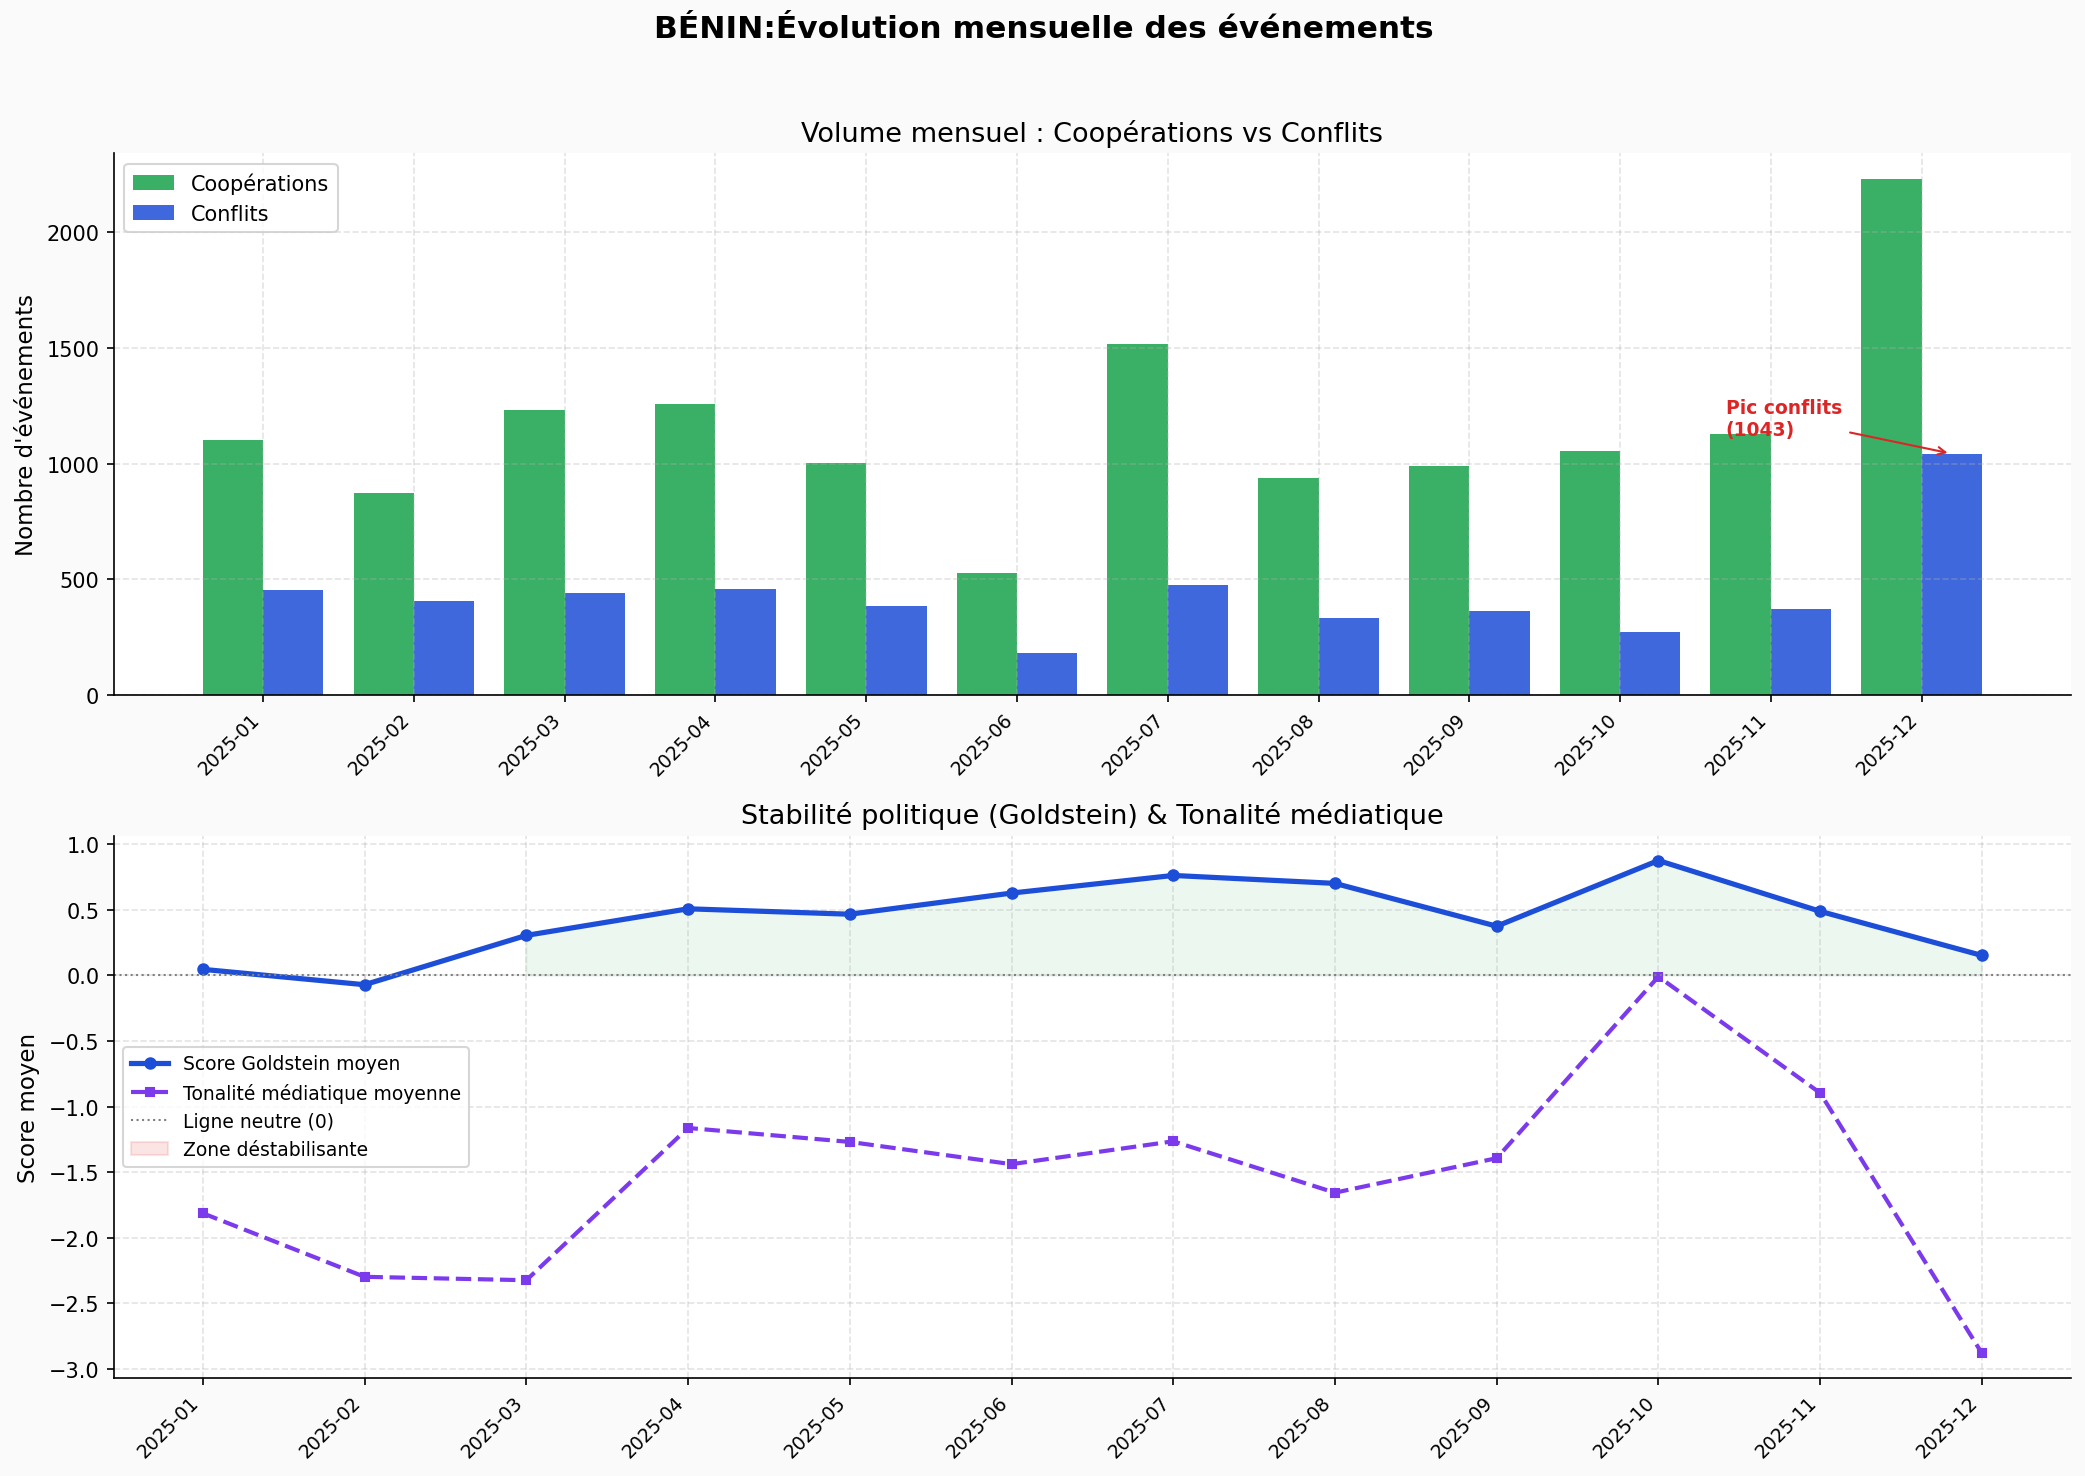

In [24]:
print("\n Évolution temporelle mensuelle...")

# Agrégation par mois : on compte les événements et on calcule
# les moyennes des indicateurs clés
mensuel = (
    df.groupby("month_year", sort=True)
    .agg(
        total      = ("GlobalEventID", "count"),
        conflits   = ("is_conflict", "sum"),
        coops      = ("is_cooperation", "sum"),
        goldstein  = ("GoldsteinScale", "mean"),
        tone       = ("AvgTone", "mean"),
    )
    .reset_index()
)

fig, axes = plt.subplots(2, 1, figsize=(14, 10))
fig.suptitle("BÉNIN:Évolution mensuelle des événements",
             fontsize=15, fontweight="bold", y=0.98)
fig.patch.set_facecolor("#FAFAFA")

# Graphique haut : volumes par type
x = range(len(mensuel))
largeur = 0.4
ax = axes[0]
bars_c = ax.bar([i - largeur/2 for i in x], mensuel["coops"],
                width=largeur, color=VERT, alpha=0.85, label="Coopérations")
bars_f = ax.bar([i + largeur/2 for i in x], mensuel["conflits"],
                width=largeur, color=BLEU, alpha=0.85, label="Conflits")

# Annoter le mois avec le plus de conflits
max_conflict_idx = mensuel["conflits"].idxmax()
ax.annotate(
    f"Pic conflits\n({mensuel.loc[max_conflict_idx,'conflits']})",
    xy=(max_conflict_idx + largeur/2, mensuel.loc[max_conflict_idx,"conflits"]),
    xytext=(max_conflict_idx + largeur/2 - 1.5,
            mensuel.loc[max_conflict_idx,"conflits"] + 80),
    arrowprops=dict(arrowstyle="->", color=ROUGE),
    color=ROUGE, fontsize=9, fontweight="bold"
)
ax.set_xticks(list(x))
ax.set_xticklabels(mensuel["month_year"], rotation=45, ha="right", fontsize=9)
ax.set_ylabel("Nombre d'événements")
ax.set_title("Volume mensuel : Coopérations vs Conflits")
ax.legend(fontsize=10)

# Graphique bas : indicateurs de qualité 
ax2 = axes[1]
ax2.plot(list(x), mensuel["goldstein"], color=BLEU, marker="o",
         linewidth=2.5, markersize=5, label="Score Goldstein moyen")
ax2.plot(list(x), mensuel["tone"], color=VIOLET, marker="s",
         linewidth=2, linestyle="--", markersize=4, label="Tonalité médiatique moyenne")
ax2.axhline(0, color="gray", linewidth=1, linestyle=":", label="Ligne neutre (0)")
ax2.fill_between(list(x), mensuel["goldstein"], 0,
                 where=(mensuel["goldstein"] < 0),
                 alpha=0.12, color=ROUGE, label="Zone déstabilisante")
ax2.fill_between(list(x), mensuel["goldstein"], 0,
                 where=(mensuel["goldstein"] >= 0),
                 alpha=0.08, color=VERT)
ax2.set_xticks(list(x))
ax2.set_xticklabels(mensuel["month_year"], rotation=45, ha="right", fontsize=9)
ax2.set_ylabel("Score moyen")
ax2.set_title("Stabilité politique (Goldstein) & Tonalité médiatique")
ax2.legend(fontsize=9)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()
plt.savefig("viz1_evolution_temporelle.png", dpi=150, bbox_inches="tight")
plt.close()


display(Image(filename='viz1_evolution_temporelle.png'))



### VISUALISATION 2 : NATURE DES ÉVÉNEMENTS (QuadClass)


[VIZ 2] Distribution QuadClass...


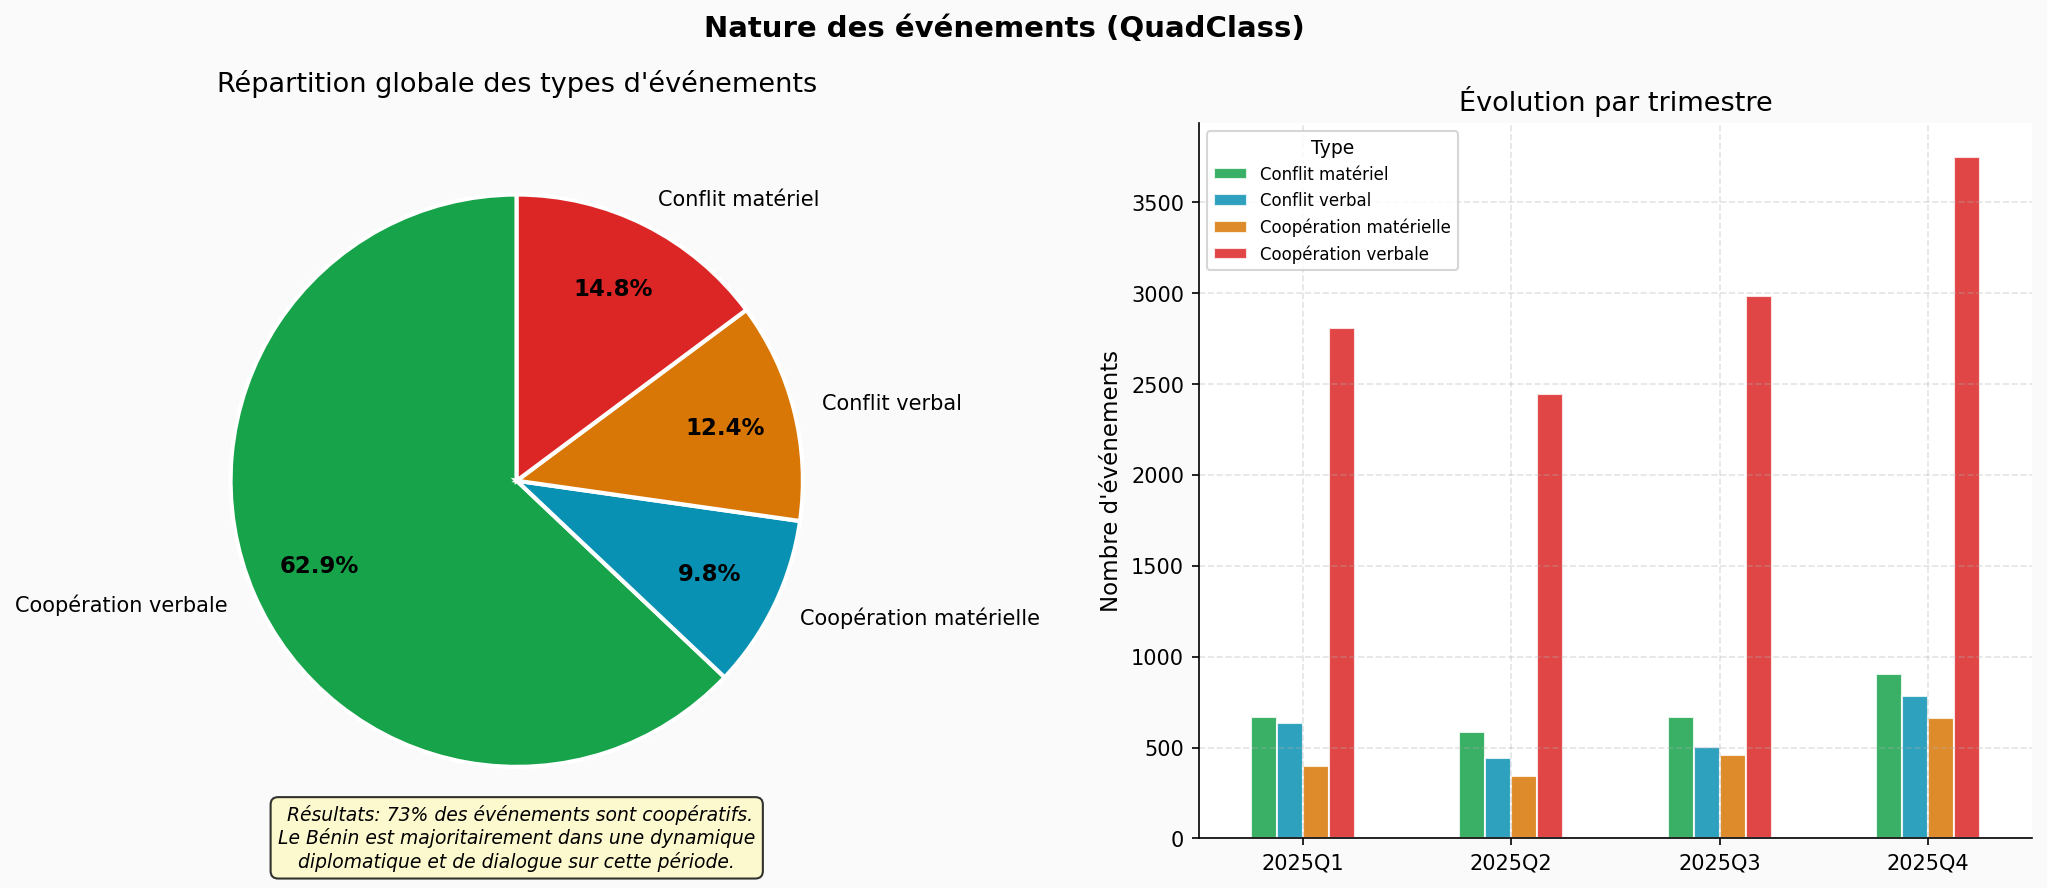

In [25]:
print("\n[VIZ 2] Distribution QuadClass...")

# analyse trimestrielles
df['trimestre'] = df['SQLDATE'].dt.to_period('Q').astype(str)
quad_counts = df["QuadClass_label"].value_counts()
quad_colors = [QUAD_COULEURS[k] for k in sorted(QUAD_LABELS.keys())
               if QUAD_LABELS[k] in quad_counts.index]
quad_sorted = quad_counts.reindex([QUAD_LABELS[k] for k in sorted(QUAD_LABELS.keys())])
quad_sorted = quad_sorted.dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Nature des événements (QuadClass)",
             fontsize=14, fontweight="bold")
fig.patch.set_facecolor("#FAFAFA")

# Camembert
colors_pie = [QUAD_COULEURS[k] for k in sorted(QUAD_LABELS.keys())]
wedges, texts, autotexts = axes[0].pie(
    quad_sorted.values,
    labels=quad_sorted.index,
    autopct="%1.1f%%",
    colors=colors_pie,
    startangle=90,
    pctdistance=0.75,
    wedgeprops=dict(edgecolor="white", linewidth=2),
)
for at in autotexts:
    at.set_fontsize(11)
    at.set_fontweight("bold")
axes[0].set_title("Répartition globale des types d'événements", pad=15)

# -- Barres avec valeurs absolues et evolution trimestrielle --
tri_quad = (
    df[df["QuadClass"].notna()]
    .groupby(["trimestre", "QuadClass_label"])["GlobalEventID"]
    .count()
    .unstack(fill_value=0)
)
tri_quad.plot(
    kind="bar", ax=axes[1],
    color=colors_pie, alpha=0.85, edgecolor="white"
)
axes[1].set_xticklabels(tri_quad.index, rotation=0, fontsize=10)
axes[1].set_xlabel("")
axes[1].set_ylabel("Nombre d'événements")
axes[1].set_title("Évolution par trimestre")
axes[1].legend(title="Type", fontsize=8, title_fontsize=9)

# Annotation insight clé
total_coop = quad_sorted.get("Coopération verbale",0) + quad_sorted.get("Coopération matérielle",0)
pct_coop = total_coop / len(df) * 100
axes[0].text(0, -1.35,
    f" Résultats: {pct_coop:.0f}% des événements sont coopératifs.\n"
    "Le Bénin est majoritairement dans une dynamique\n"
    "diplomatique et de dialogue sur cette période.",
    ha="center", fontsize=9, style="italic",
    bbox=dict(boxstyle="round,pad=0.4", facecolor="#FEF9C3", alpha=0.8))

plt.tight_layout()
plt.show()
plt.savefig("viz2_distribution_quad_class.png", dpi=150, bbox_inches="tight")
plt.close()
display(Image(filename='viz2_distribution_quad_class.png'))

L'analyse de la nature des événements pour la période 2025-2026 au Bénin révèle les points suivants() :

**Dominance de la coopération** : Environ 73% des événements enregistrés relèvent de la coopération (verbale ou matérielle).

**Répartition par type :**

- Coopération verbale : Il s'agit de la catégorie la plus représentée avec 62,9% des interactions.

- Conflit matériel : Cette catégorie représente 14,8% des événements.

- Conflit verbal : Elle constitue 12,4% du total.

- Coopération matérielle : Ce type d'événement compte pour 9,8% de la distribution.

- Évolution trimestrielle : On observe une augmentation notable du volume d'événements, particulièrement pour la coopération verbale, au cours du quatrième trimestre (2025Q4).


**Conclusion** : La prédominance massive des interactions coopératives suggère que le Bénin s'inscrit principalement dans une dynamique de dialogue et de diplomatie sur la scène médiatique mondiale durant cette période.

### VISUALISATION 3 : ANALYSE DE LA STABILITÉ POLITIQUE DU BÉNIN


[VIZ 3] Analyse Goldstein...


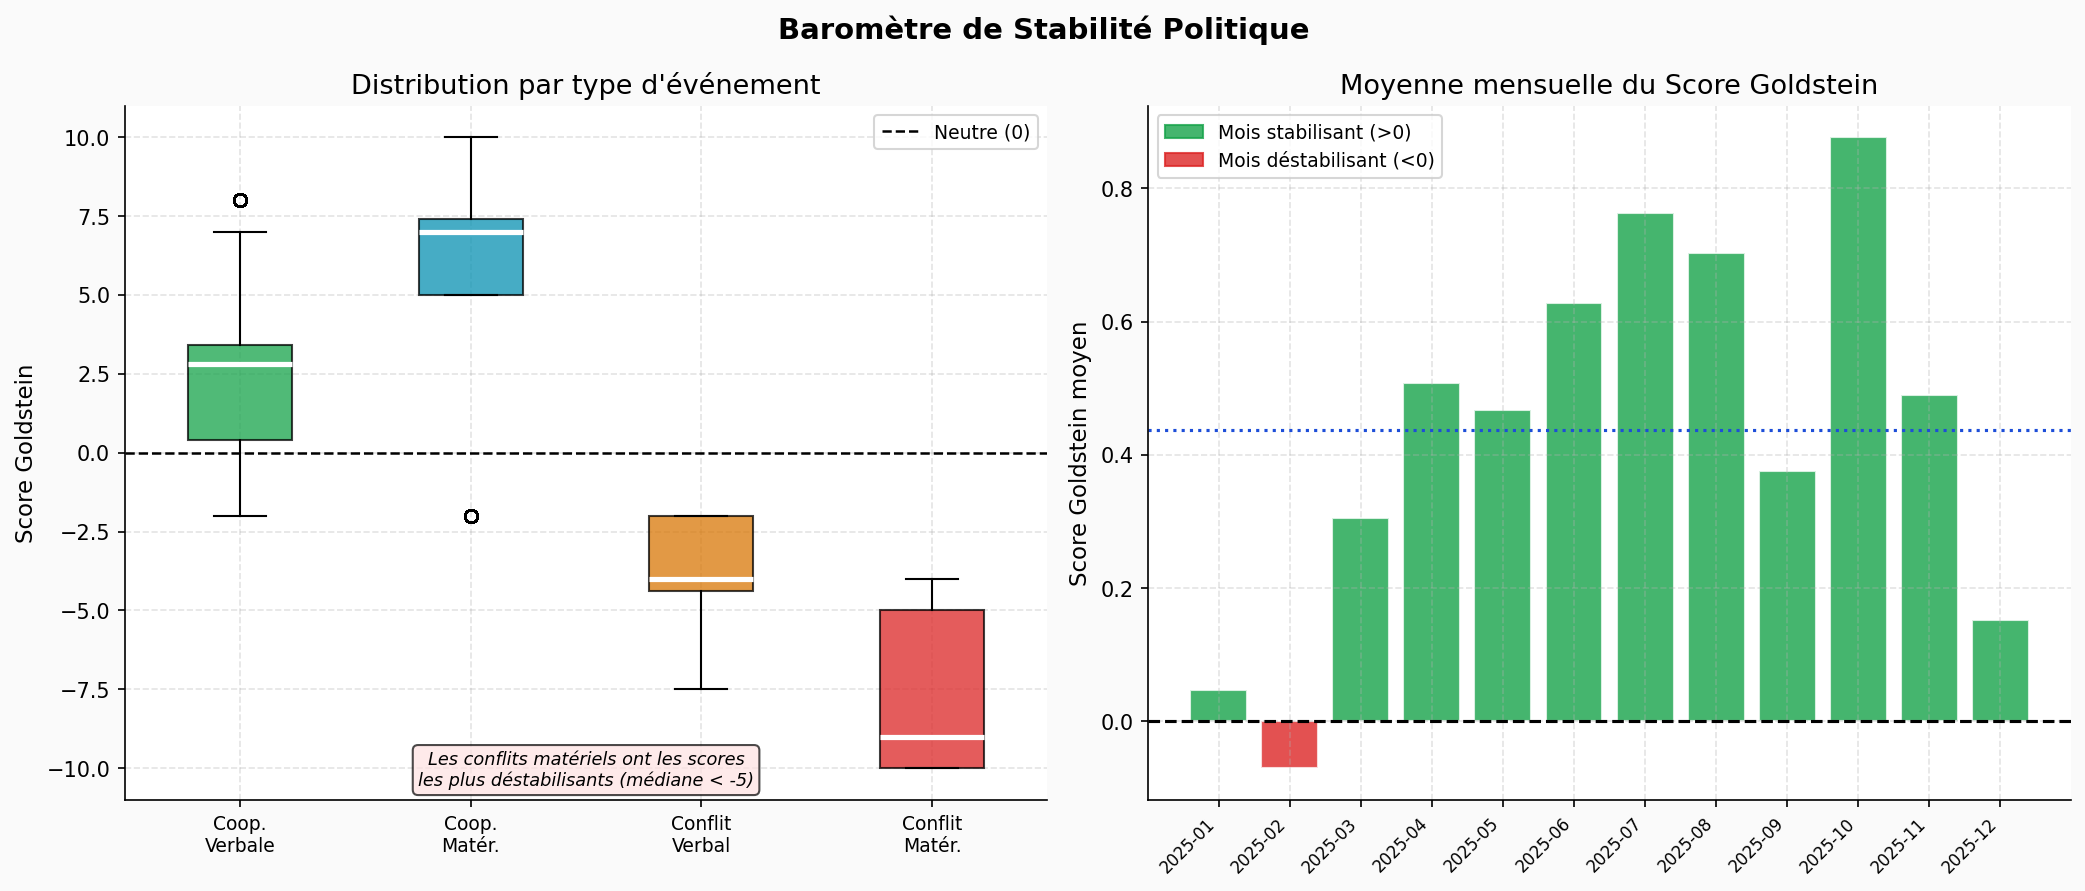

In [26]:
print("\n[VIZ 3] Analyse Goldstein...")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Baromètre de Stabilité Politique",
             fontsize=14, fontweight="bold")
fig.patch.set_facecolor("#FAFAFA")

# -- Distribution par QuadClass --
ax = axes[0]
quad_order = [QUAD_LABELS[k] for k in [1, 2, 3, 4]]
data_box = [
    df[df["QuadClass_label"] == lbl]["GoldsteinScale"].dropna().values
    for lbl in quad_order
]
bp = ax.boxplot(data_box, patch_artist=True, notch=False,
                medianprops=dict(color="white", linewidth=2.5))
box_colors = [VERT, CYAN, ORANGE, ROUGE]
for patch, color in zip(bp["boxes"], box_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)
ax.axhline(0, color="black", linewidth=1.2, linestyle="--", label="Neutre (0)")
ax.set_xticklabels(
    ["Coop.\nVerbale","Coop.\nMatér.","Conflit\nVerbal","Conflit\nMatér."],
    fontsize=9
)
ax.set_ylabel("Score Goldstein")
ax.set_title("Distribution par type d'événement")
ax.legend(fontsize=9)

# Annotation
ax.text(0.5, 0.02,
    "Les conflits matériels ont les scores\nles plus déstabilisants (médiane < -5)",
    transform=ax.transAxes, ha="center", fontsize=8.5, style="italic",
    bbox=dict(boxstyle="round", facecolor="#FEE2E2", alpha=0.7))

# -- Évolution du Goldstein cumulé mensuel --
ax2 = axes[1]
goldstein_mensuel = df.groupby("month_year")["GoldsteinScale"].mean().reset_index()
goldstein_mensuel = goldstein_mensuel.sort_values("month_year")
x_vals = range(len(goldstein_mensuel))

couleurs_bars = [ROUGE if v < 0 else VERT
                 for v in goldstein_mensuel["GoldsteinScale"]]
ax2.bar(x_vals, goldstein_mensuel["GoldsteinScale"],
        color=couleurs_bars, alpha=0.8, edgecolor="white")
ax2.axhline(0, color="black", linewidth=1.5, linestyle="--")
ax2.axhline(goldstein_mensuel["GoldsteinScale"].mean(),
            color=BLEU, linewidth=1.5, linestyle=":",
            label=f"Moy. globale ({goldstein_mensuel['GoldsteinScale'].mean():.2f})")
ax2.set_xticks(list(x_vals))
ax2.set_xticklabels(goldstein_mensuel["month_year"], rotation=45, ha="right", fontsize=8)
ax2.set_ylabel("Score Goldstein moyen")
ax2.set_title("Moyenne mensuelle du Score Goldstein")
ax2.legend(fontsize=9)

# Patch de légende
patch_pos = mpatches.Patch(color=VERT, alpha=0.8, label="Mois stabilisant (>0)")
patch_neg = mpatches.Patch(color=ROUGE, alpha=0.8, label="Mois déstabilisant (<0)")
ax2.legend(handles=[patch_pos, patch_neg], fontsize=9)

plt.tight_layout()
plt.show()
plt.savefig("viz3_Goldstein_analyse.png", dpi=150, bbox_inches="tight")

plt.close()
display(Image(filename='viz3_Goldstein_analyse.png'))


### VISUALISATION 4 : Analyse de la tonalité moyenne (Sentiment)AVGTONE



[VIZ 4] Analyse tonalité médiatique...


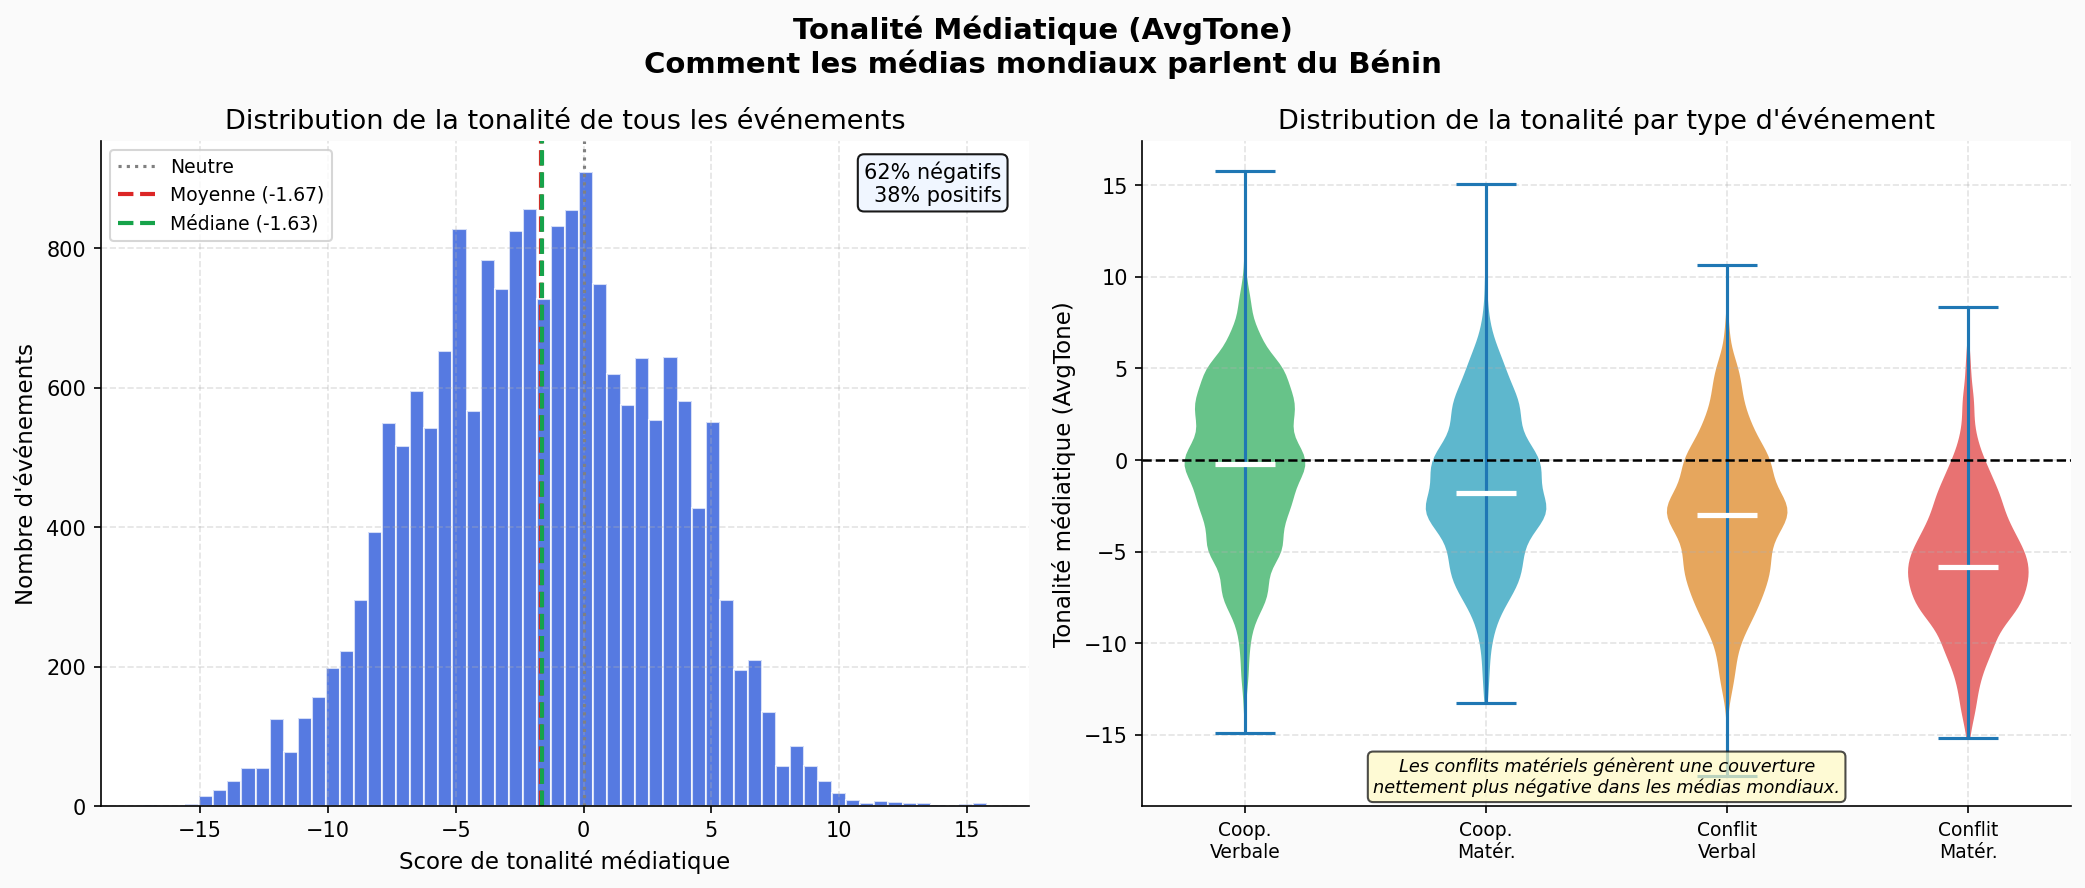

In [30]:
print("\n[VIZ 4] Analyse tonalité médiatique...")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Tonalité Médiatique (AvgTone)\nComment les médias mondiaux parlent du Bénin",
             fontsize=14, fontweight="bold")
fig.patch.set_facecolor("#FAFAFA")

# -- Histogramme de distribution --
ax = axes[0]
ax.hist(df["AvgTone"].dropna(), bins=60, color=BLEU, alpha=0.75, edgecolor="white")
ax.axvline(0, color="gray", linewidth=1.5, linestyle=":", label="Neutre")
ax.axvline(df["AvgTone"].mean(), color=ROUGE, linewidth=2,
           linestyle="--", label=f"Moyenne ({df['AvgTone'].mean():.2f})")
ax.axvline(df["AvgTone"].median(), color=VERT, linewidth=2,
           linestyle="--", label=f"Médiane ({df['AvgTone'].median():.2f})")
ax.set_xlabel("Score de tonalité médiatique")
ax.set_ylabel("Nombre d'événements")
ax.set_title("Distribution de la tonalité de tous les événements")
ax.legend(fontsize=9)
ax.text(0.97, 0.97,
    f"{(df['AvgTone'] < 0).mean()*100:.0f}% négatifs\n{(df['AvgTone'] >= 0).mean()*100:.0f}% positifs",
    transform=ax.transAxes, ha="right", va="top", fontsize=10,
    bbox=dict(boxstyle="round", facecolor="#EFF6FF", alpha=0.9))

# -- Violin plot : tonalité par type --
ax2 = axes[1]
df_violin = df[df["QuadClass_label"].notna()].copy()
quad_order_v = [QUAD_LABELS[k] for k in [1,2,3,4] if QUAD_LABELS[k] in df_violin["QuadClass_label"].unique()]

violin_data = [df_violin[df_violin["QuadClass_label"]==lbl]["AvgTone"].dropna().values
               for lbl in quad_order_v]
parts = ax2.violinplot(violin_data, positions=range(len(quad_order_v)),
                        showmedians=True, showextrema=True)
for i, (pc, color) in enumerate(zip(parts["bodies"], box_colors)):
    pc.set_facecolor(color)
    pc.set_alpha(0.65)
parts["cmedians"].set_color("white")
parts["cmedians"].set_linewidth(2.5)
ax2.axhline(0, color="black", linewidth=1.2, linestyle="--")
ax2.set_xticks(range(len(quad_order_v)))
ax2.set_xticklabels(["Coop.\nVerbale","Coop.\nMatér.","Conflit\nVerbal","Conflit\nMatér."],
                     fontsize=9)
ax2.set_ylabel("Tonalité médiatique (AvgTone)")
ax2.set_title("Distribution de la tonalité par type d'événement")
ax2.text(0.5, 0.02,
    "Les conflits matériels génèrent une couverture\nnettement plus négative dans les médias mondiaux.",
    transform=ax2.transAxes, ha="center", fontsize=8.5, style="italic",
    bbox=dict(boxstyle="round", facecolor="#FEF9C3", alpha=0.7))

plt.tight_layout()
plt.savefig("viz4_ton_mediatique.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close()
display(Image("viz4_ton_mediatique.png"))

L'analyse de la tonalité médiatique (AvgTone) pour le Bénin sur la période 2025-2026 met en lumière la perception globale dans les médias mondiaux :

- Une tonalité globalement négative : La distribution des scores montre que 68% des événements ont une tonalité négative, avec une moyenne de **-1,67** et une médiane de **-1,63**.

- Sensibilité aux conflits : Le graphique en violon révèle que les conflits matériels (en rouge) sont les événements qui génèrent la couverture la plus sombre et la plus négative dans les médias internationaux.

- Contraste avec la coopération : Bien que plus fréquentes, les coopérations verbales (en vert) affichent une tonalité beaucoup plus neutre, oscillant autour de zéro, ce qui indique un traitement journalistique plus factuel ou positif pour ces interactions diplomatiques.

**Observation**: Malgré une dynamique majoritairement coopérative (vu précédemment), le récit médiatique mondial reste dominé par des scores négatifs, soulignant l'impact disproportionné des événements conflictuels sur l'image de marque du pays.

### VISUALISATION 5 : ACTEURS PRINCIPAUX


[VIZ 5] Analyse des acteurs...


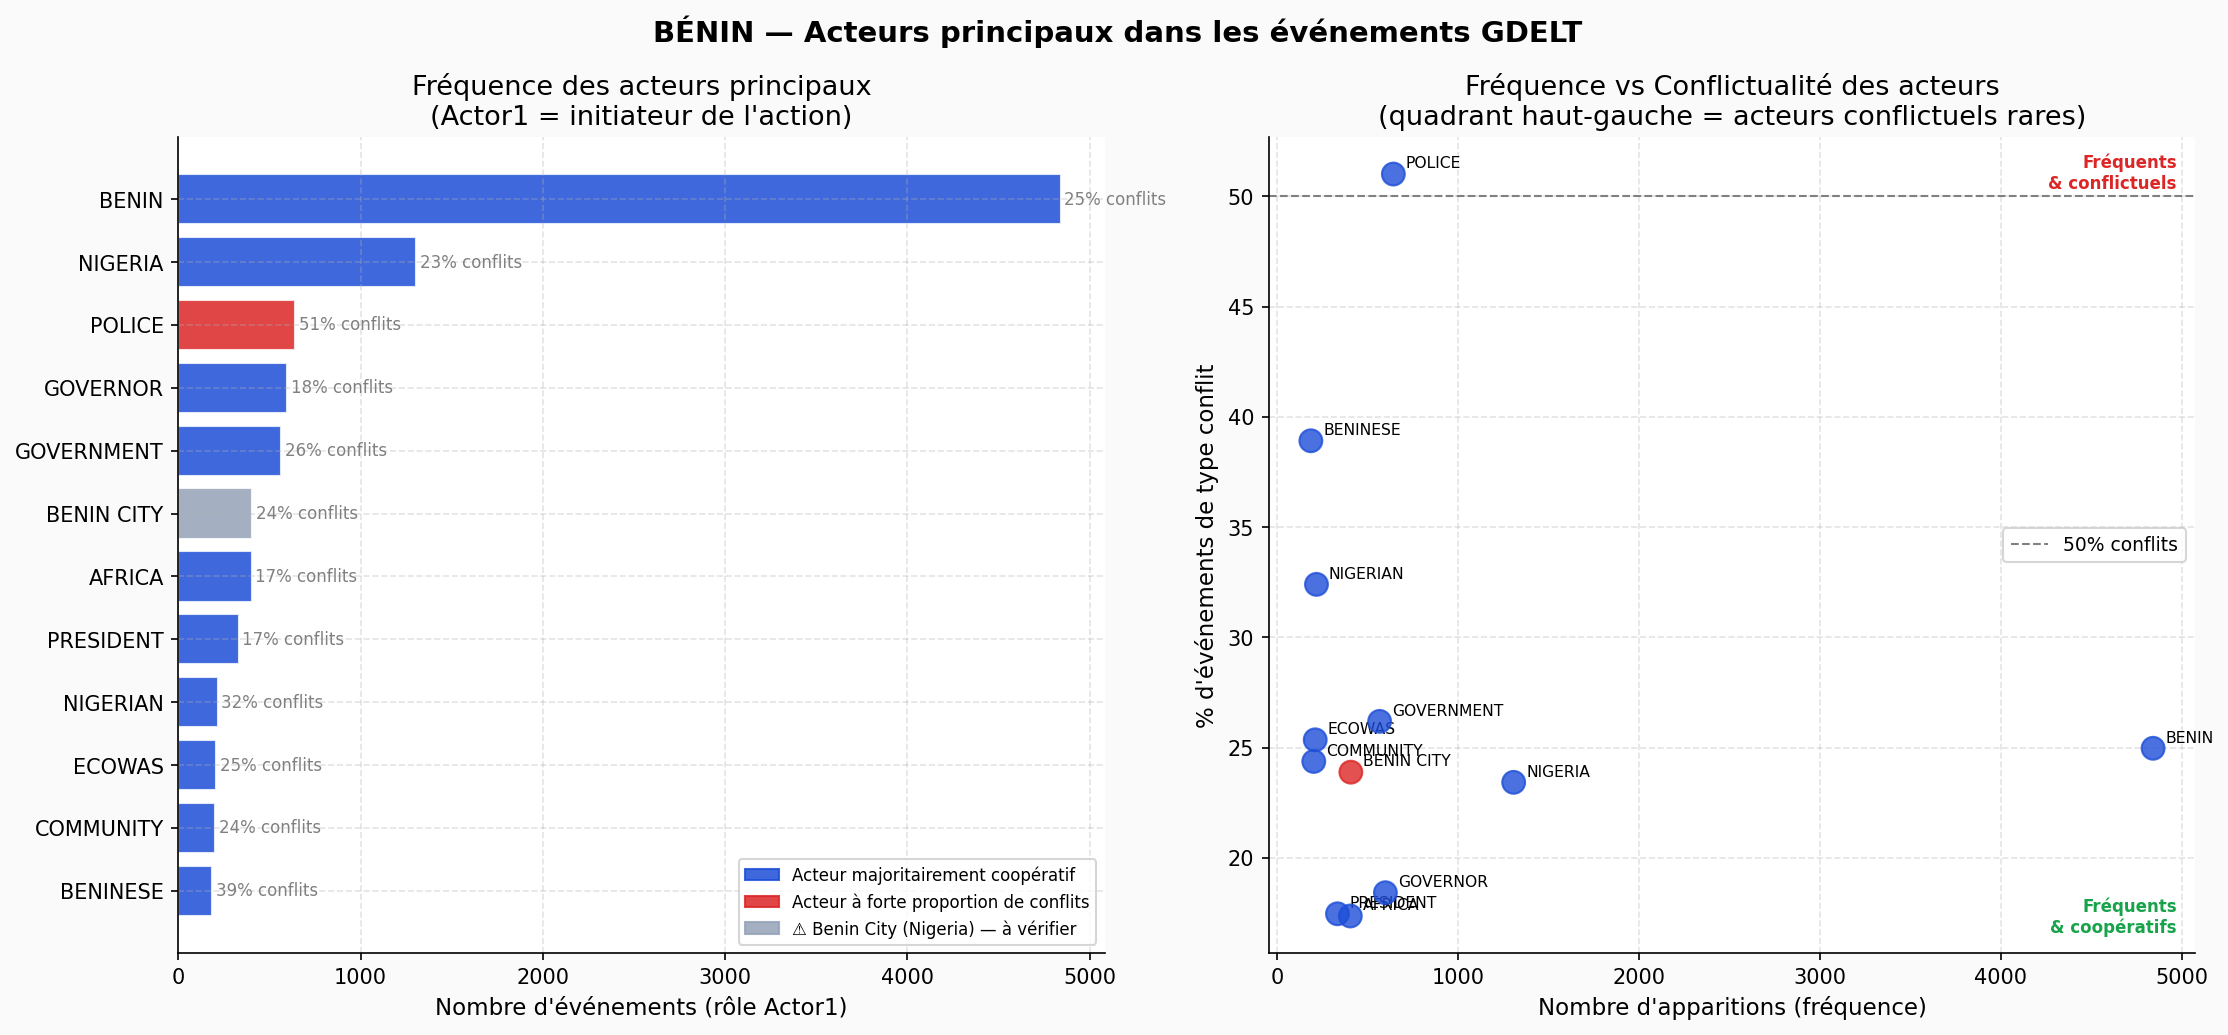

In [ ]:
print("\n[VIZ 5] Analyse des acteurs...")

# Nettoyer les acteurs vides ou nan
df_actors = df[df["Actor1Name"].notna() & (df["Actor1Name"] != "nan")].copy()

# Top 12 acteurs par fréquence
top_acteurs = df_actors["Actor1Name"].value_counts().head(12)

# Pour chaque acteur, calculer le % de conflits qu'il initie
pct_conflict_actor = {}
for acteur in top_acteurs.index:
    sous_df = df_actors[df_actors["Actor1Name"] == acteur]
    pct_conflict_actor[acteur] = sous_df["is_conflict"].mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(15, 7))
fig.suptitle("Acteurs principaux dans les événements GDELT",
             fontsize=14, fontweight="bold")
fig.patch.set_facecolor("#FAFAFA")

# barres horizontales
ax = axes[0]
couleurs_acteurs = []
for acteur in top_acteurs.index:
    if acteur == "BENIN CITY":
        couleurs_acteurs.append("#94A3B8")   # Gris = donnée suspecte
    elif pct_conflict_actor.get(acteur, 0) > 40:
        couleurs_acteurs.append(ROUGE)
    else:
        couleurs_acteurs.append(BLEU)

bars = ax.barh(top_acteurs.index[::-1], top_acteurs.values[::-1],
               color=couleurs_acteurs[::-1], alpha=0.85, edgecolor="white")

# Ajouter le % de conflits sur chaque barre
for i, (acteur, val) in enumerate(zip(top_acteurs.index[::-1], top_acteurs.values[::-1])):
    pct = pct_conflict_actor.get(acteur, 0)
    ax.text(val + 20, i, f"{pct:.0f}% conflits", va="center", fontsize=8, color="gray")

ax.set_xlabel("Nombre d'événements (rôle Actor1)")
ax.set_title("Fréquence des acteurs principaux\n(Actor1 = initiateur de l'action)")

# Légende manuelle
patch_bleu  = mpatches.Patch(color=BLEU,     alpha=0.85, label="Acteur majoritairement coopératif")
patch_rouge = mpatches.Patch(color=ROUGE,    alpha=0.85, label="Acteur à forte proportion de conflits")
patch_gris  = mpatches.Patch(color="#94A3B8",alpha=0.85, label="⚠ Benin City (Nigeria) — à vérifier")
ax.legend(handles=[patch_bleu, patch_rouge, patch_gris], fontsize=8, loc="lower right")

# -- Scatter : fréquence vs % conflits --
ax2 = axes[1]
freq_vals = [top_acteurs[a] for a in top_acteurs.index]
conf_vals = [pct_conflict_actor[a] for a in top_acteurs.index]
scatter_colors = [ROUGE if a == "BENIN CITY" else BLEU for a in top_acteurs.index]

sc = ax2.scatter(freq_vals, conf_vals, s=120, c=scatter_colors, alpha=0.8, zorder=5)
for i, acteur in enumerate(top_acteurs.index):
    ax2.annotate(acteur, (freq_vals[i], conf_vals[i]),
                 textcoords="offset points", xytext=(6, 3), fontsize=7.5)

ax2.axhline(50, color="gray", linewidth=1, linestyle="--", label="50% conflits")
ax2.set_xlabel("Nombre d'apparitions (fréquence)")
ax2.set_ylabel("% d'événements de type conflit")
ax2.set_title("Fréquence vs Conflictualité des acteurs\n(quadrant haut-gauche = acteurs conflictuels rares)")
ax2.legend(fontsize=9)

# Annotation quadrants
ax2.text(0.98, 0.98, "Fréquents\n& conflictuels",
         transform=ax2.transAxes, ha="right", va="top",
         fontsize=8, color=ROUGE, fontweight="bold")
ax2.text(0.98, 0.02, "Fréquents\n& coopératifs",
         transform=ax2.transAxes, ha="right", va="bottom",
         fontsize=8, color=VERT, fontweight="bold")

plt.tight_layout()
plt.show()
plt.savefig("viz5_acteurs.png", dpi=150, bbox_inches="tight")
plt.close()
display(Image("viz5_acteurs.png"))

Cette analyse des acteurs identifie les forces en présence et leur nature d'interaction :

- Acteurs Dominicaux : L'acteur *BENIN* est omniprésent, suivi par le *NIGERIA*, confirmant l'importance des relations bilatérales. Tous deux affichent un profil majoritairement coopératif (environ 25% de conflits).


- Profils Conflictuels : La *POLICE* se détache nettement avec 51% d'événements de type conflit, ce qui est cohérent pour un acteur souvent associé à des interventions ou des tensions sécuritaires.


- Acteurs Institutionnels : Le GOVERNMENT", le PRESIDENT et les GOVERNOR présentent des taux de conflictualité relativement bas (entre 17% et 26%), suggérant une communication axée sur la coopération ou la gestion administrative.


- Point de Vigilance: *BENIN CITY* apparaît fréquemment mais doit être traité avec prudence, car il faire référence à la ville nigériane plutôt qu'à l'État béninois.


- Acteurs Communautaires : Les **BENINESE** et la **COMMUNITY** sont également des acteurs clés, les premiers montrant une tendance plus marquée vers des événements de tension (39%) que les seconds (24%)

### VISUALISATION 6 : GÉOGRAPHIE DES ÉVÉNEMENTS


[VIZ 6] Analyse géographique...


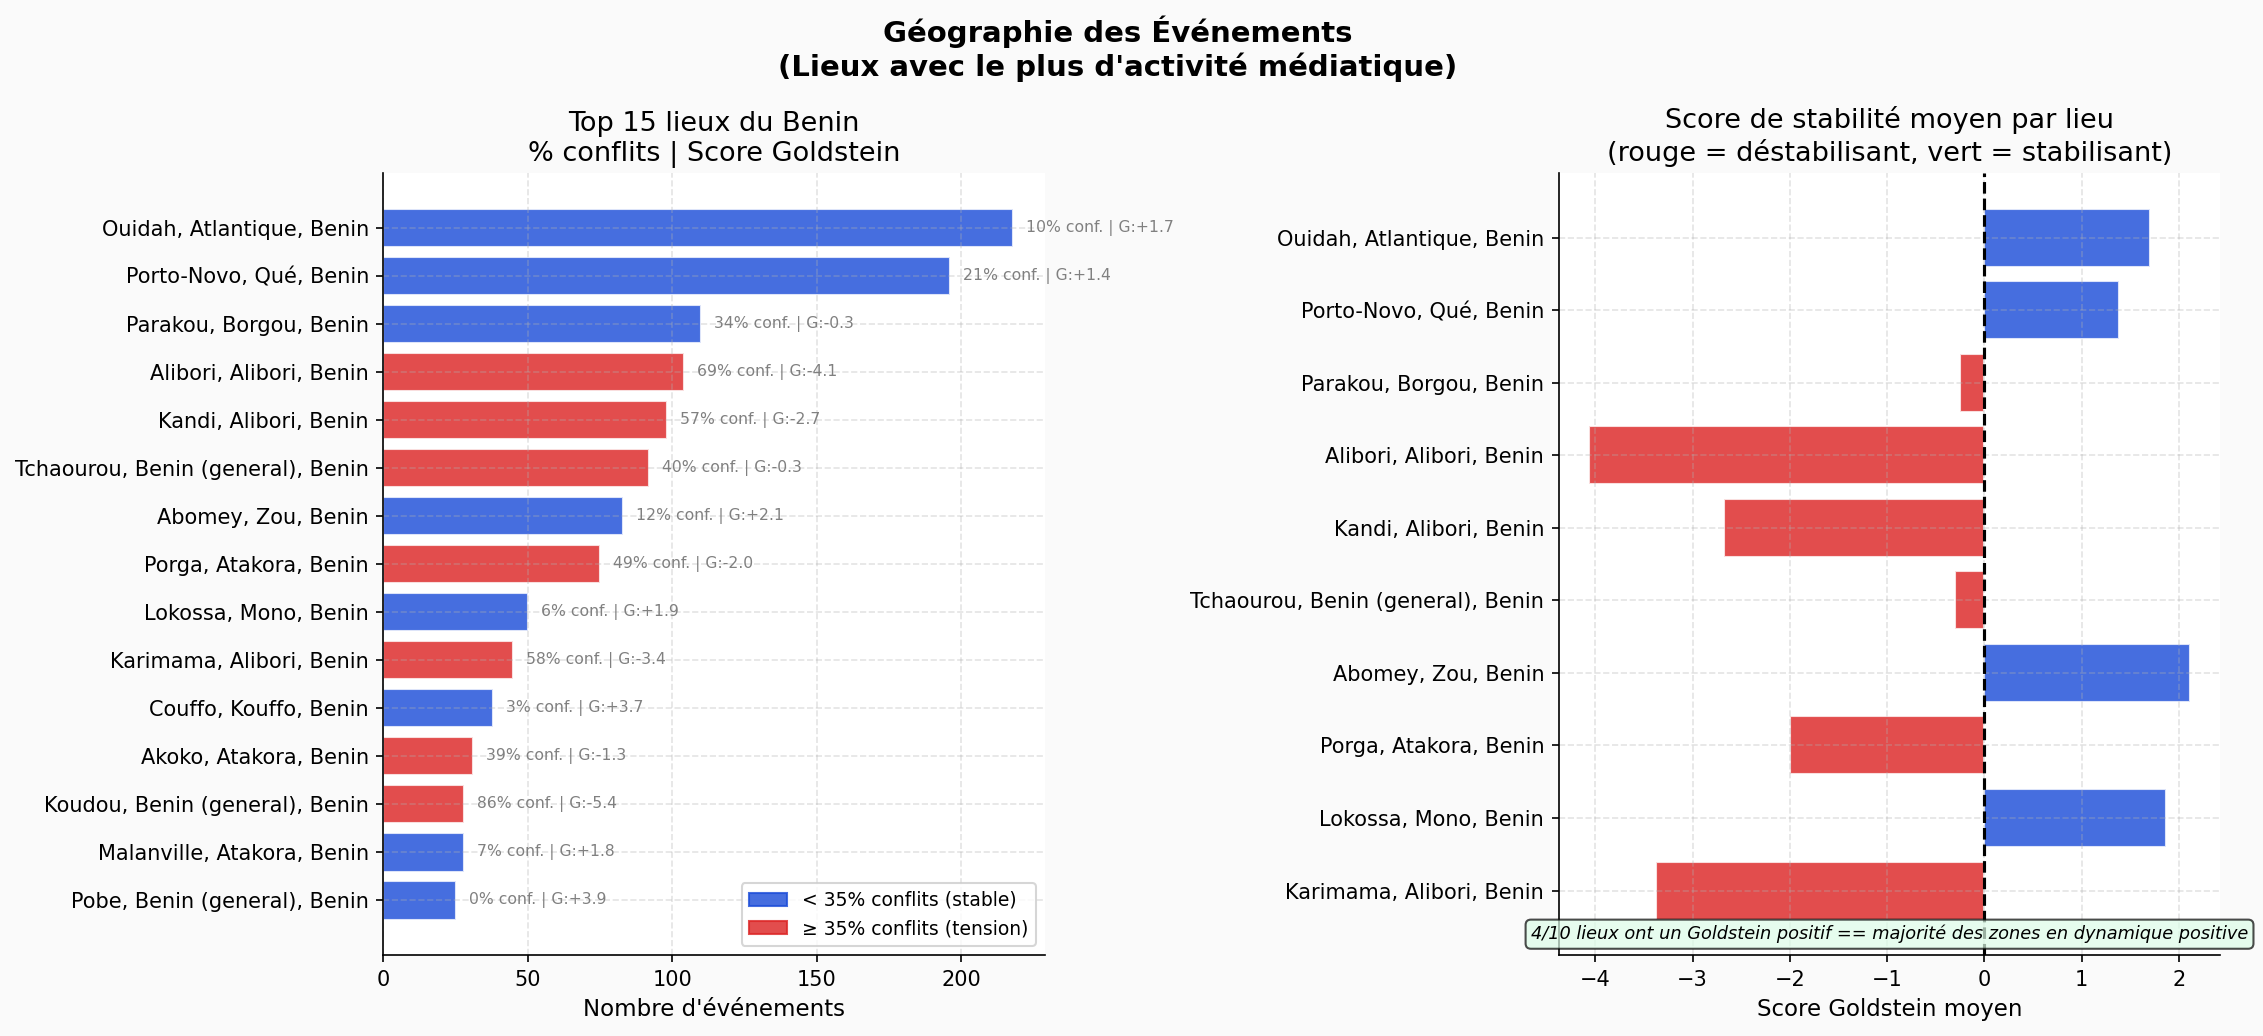

In [35]:
print("\n[VIZ 6] Analyse géographique...")

# Top lieux par nombre d'événements (exclure "Benin" générique)
df_geo = df[
    (df["ActionGeo_FullName"].notna()) &
    (df["ActionGeo_FullName"] != "Benin") &
    (df["ActionGeo_FullName"] != "nan")
].copy()

top_lieux = df_geo["ActionGeo_FullName"].value_counts().head(15)

# Calculer le % de conflits par lieu
conflict_lieu = {}
for lieu in top_lieux.index:
    sous = df_geo[df_geo["ActionGeo_FullName"] == lieu]
    conflict_lieu[lieu] = sous["is_conflict"].mean() * 100

goldstein_lieu = {}
for lieu in top_lieux.index:
    sous = df_geo[df_geo["ActionGeo_FullName"] == lieu]
    goldstein_lieu[lieu] = sous["GoldsteinScale"].mean()

fig, axes = plt.subplots(1, 2, figsize=(15, 7))
fig.suptitle("Géographie des Événements\n(Lieux avec le plus d'activité médiatique)",
             fontsize=14, fontweight="bold")
fig.patch.set_facecolor("#FAFAFA")

# Top lieux par fréquence
ax = axes[0]
couleurs_lieux = [ROUGE if conflict_lieu.get(l,0) > 35 else BLEU
                  for l in top_lieux.index[::-1]]
ax.barh(top_lieux.index[::-1], top_lieux.values[::-1],
        color=couleurs_lieux, alpha=0.82, edgecolor="white")
for i, (lieu, val) in enumerate(zip(top_lieux.index[::-1], top_lieux.values[::-1])):
    pct = conflict_lieu.get(lieu, 0)
    gold = goldstein_lieu.get(lieu, 0)
    ax.text(val + 1, i, f"  {pct:.0f}% conf. | G:{gold:+.1f}",
            va="center", fontsize=7.5, color="gray")

ax.set_xlabel("Nombre d'événements")
ax.set_title("Top 15 lieux du Benin\n% conflits | Score Goldstein")
patch_v = mpatches.Patch(color=BLEU,  alpha=0.82, label="< 35% conflits (stable)")
patch_r = mpatches.Patch(color=ROUGE, alpha=0.82, label="≥ 35% conflits (tension)")
ax.legend(handles=[patch_v, patch_r], fontsize=9)

# -- Score Goldstein par lieu (top 10) --
ax2 = axes[1]
top10_lieux = list(top_lieux.index[:10])
gold_vals   = [goldstein_lieu[l] for l in top10_lieux]
couleurs_gold = [ROUGE if g < 0 else BLEU for g in gold_vals]
bars = ax2.barh(top10_lieux[::-1], gold_vals[::-1],
                color=couleurs_gold[::-1], alpha=0.82, edgecolor="white")
ax2.axvline(0, color="black", linewidth=1.5, linestyle="--")
ax2.set_xlabel("Score Goldstein moyen")
ax2.set_title("Score de stabilité moyen par lieu\n(rouge = déstabilisant, vert = stabilisant)")

# Annotation finale
nb_stable = sum(1 for g in gold_vals if g >= 0)
ax2.text(0.5, 0.02,
    f"{nb_stable}/{len(top10_lieux)} lieux ont un Goldstein positif == majorité des zones en dynamique positive",
    transform=ax2.transAxes, ha="center", fontsize=8.5, style="italic",
    bbox=dict(boxstyle="round", facecolor="#DCFCE7", alpha=0.7))

plt.tight_layout()
plt.savefig("viz6_geographie.png", dpi=150, bbox_inches="tight")
plt.close()
display(Image('viz6_geographie.png'))

L'analyse géographique révèle une fracture nette dans la stabilité du pays sur la période 2025-2026 :

- Pôles de Stabilité (Sud et Centre) : Des villes comme Ouidah, Porto-Novo, Abomey et Lokossa affichent des scores Goldstein positifs et de faibles taux de conflictualité (souvent inférieurs à 20%). Ces zones portent la dynamique positive et diplomatique du pays.



- Zones de Tension (Nord) : On observe une concentration alarmante d'événements conflictuels dans le département de l'Alibori (Kandi, Karimama, Alibori) et l'Atakora (Porga, Akoko). Ces localités présentent des scores Goldstein fortement négatifs (jusqu'à -4.1 pour Alibori) et des taux de conflits dépassant les 50%, reflétant probablement des enjeux sécuritaires frontaliers.


- Le cas particulier de Parakou : Bien que très active médiatiquement, la ville de Parakou se situe à la charnière avec un score Goldstein légèrement négatif (-0.3) et un taux de conflit de 34%, marquant la transition entre le sud stable et le nord sous pression.


**Bilan Global** : Bien que 40% des lieux majeurs maintiennent un indicateur de stabilité positif, la sévérité des scores négatifs dans le Grand Nord suggère que les crises locales dans ces régions dominent l'impact médiatique négatif du Bénin à l'échelle internationale.

### VISUALISATION 7 : MATRICE DE CORRÉLATION


[VIZ 7] Matrice de corrélation...


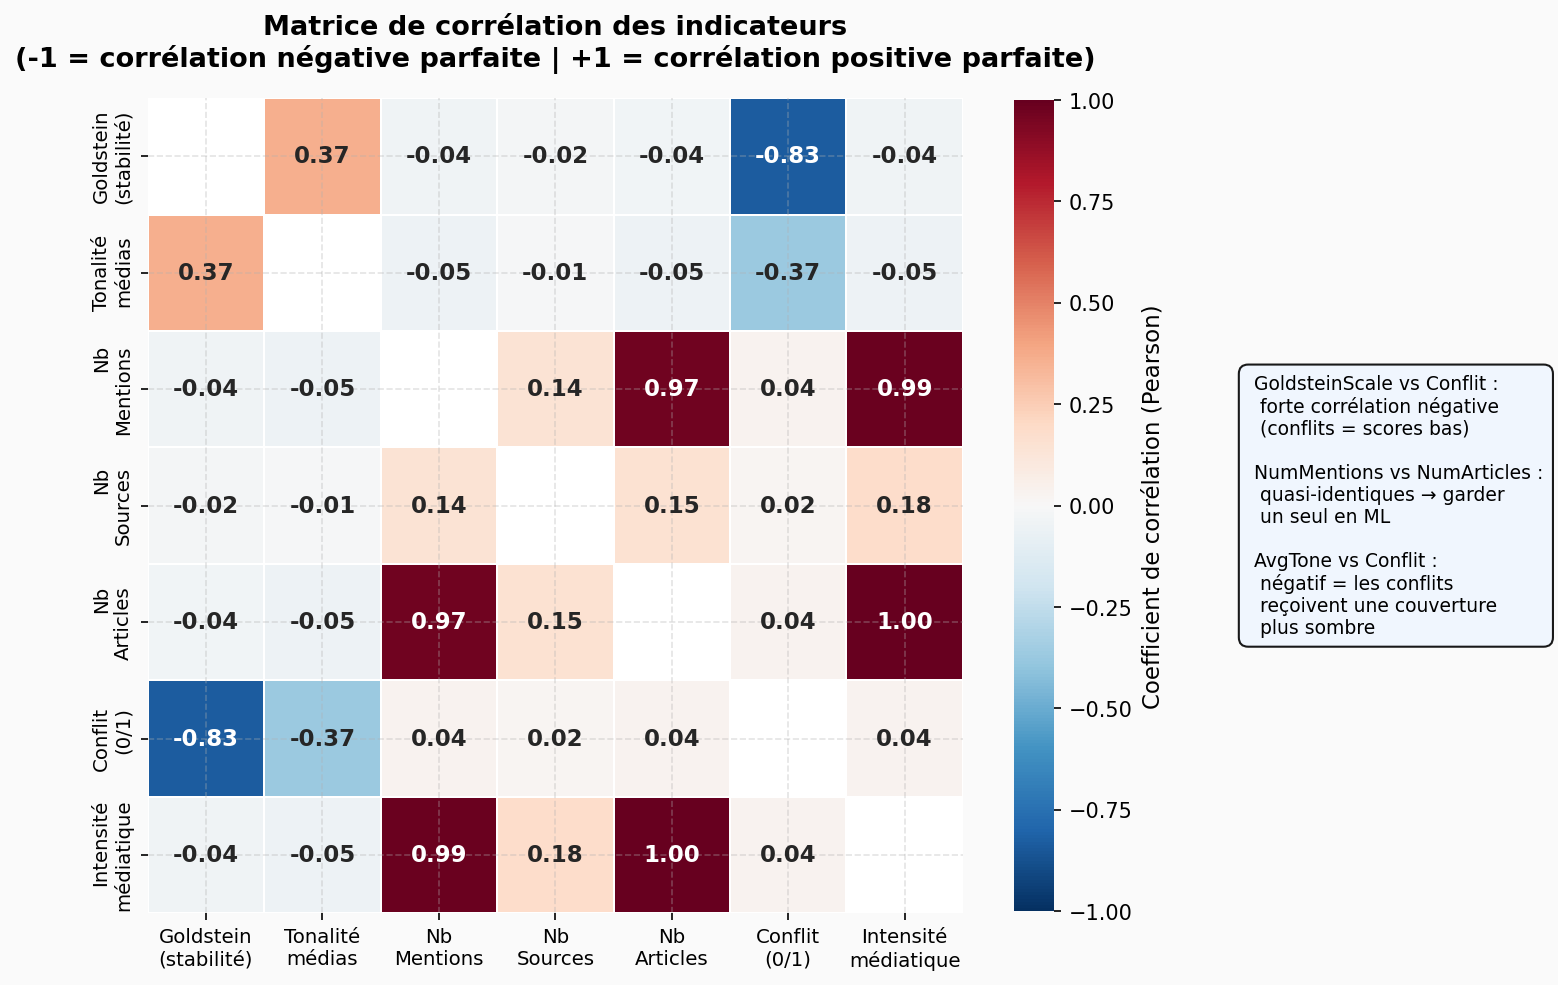

In [39]:
print("\n[VIZ 7] Matrice de corrélation...")

cols_corr = ["GoldsteinScale","AvgTone","NumMentions",
             "NumSources","NumArticles","is_conflict","media_intensity"]
corr_matrix = df[cols_corr].corr()

# Labels plus lisibles pour les journalistes
labels_lisibles = {
    "GoldsteinScale"  : "Goldstein\n(stabilité)",
    "AvgTone"         : "Tonalité\nmédias",
    "NumMentions"     : "Nb\nMentions",
    "NumSources"      : "Nb\nSources",
    "NumArticles"     : "Nb\nArticles",
    "is_conflict"     : "Conflit\n(0/1)",
    "media_intensity" : "Intensité\nmédiatique"
}
corr_matrix_renamed = corr_matrix.rename(
    index=labels_lisibles, columns=labels_lisibles
)

fig, ax = plt.subplots(figsize=(10, 8))
fig.patch.set_facecolor("#FAFAFA")
mask = np.zeros_like(corr_matrix_renamed, dtype=bool)
np.fill_diagonal(mask, True)   # Masquer la diagonale (corrélation avec soi-même = 1)

sns.heatmap(
    corr_matrix_renamed,
    ax=ax,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    vmin=-1, vmax=1,
    mask=mask,
    linewidths=0.8,
    linecolor="white",
    annot_kws={"size": 11, "weight": "bold"},
    square=True,
    cbar_kws={"shrink": 0.8, "label": "Coefficient de corrélation (Pearson)"}
)
ax.set_title(
    "Matrice de corrélation des indicateurs\n"
    "(-1 = corrélation négative parfaite | +1 = corrélation positive parfaite)",
    fontsize=13, fontweight="bold", pad=15
)
ax.tick_params(axis="both", labelsize=9.5)

# Encadrer les corrélations fortes à signaler
ax.text(1.35, 0.5,
    " GoldsteinScale vs Conflit :\n  forte corrélation négative\n  (conflits = scores bas)\n\n"
    " NumMentions vs NumArticles :\n  quasi-identiques → garder\n  un seul en ML\n\n"
    " AvgTone vs Conflit :\n  négatif = les conflits\n  reçoivent une couverture\n  plus sombre",
    transform=ax.transAxes, fontsize=9, va="center",
    bbox=dict(boxstyle="round,pad=0.5", facecolor="#EFF6FF", alpha=0.9)
)

plt.tight_layout()
plt.savefig("viz7_correlation.png", dpi=150, bbox_inches="tight")
plt.close()
display(Image("viz7_correlation.png"))

In [15]:

# POURQUOI : Un journaliste a besoin de savoir QUAND les événements
# se concentrent. Des pics d'activité peuvent signaler des élections,
# des crises sécuritaires, des sommets diplomatiques, etc.
#
# ON ATTEND : Une courbe montrant le rythme mensuel des événements,
# différenciant conflits et coopérations pour voir si la situation
# s'améliore ou se détériore dans le temps.
# ================================================================


# ================================================================

# POURQUOI : La classification en 4 types (QuadClass) est le premier
# indicateur synthétique pour comprendre le climat politique.
# 63% de coopérations verbales = discours diplomatiques, accords, etc.
# 14% de conflits matériels = actes de violence, affrontements concrets.
# Cette répartition dit à un journaliste comment "cadrer" sa couverture.
# ================================================================

# ================================================================

# ================================================================
# POURQUOI : Le score Goldstein (-10 à +10) mesure l'impact théorique
# d'un événement sur la STABILITÉ d'un pays.
#  > 0 = stabilisant (coopération, accord, aide)
#  < 0 = déstabilisant (conflit, répression, menace)
# En agrégeant par mois, on obtient un BAROMÈTRE de stabilité
# beaucoup plus nuancé que le simple comptage d'événements.
# Un journaliste peut voir si la situation se dégrade même si le
# nombre d'événements reste stable.
# ================================================================

print("   ✅ Sauvegardé : viz3_goldstein.png")

# ================================================================
# ================================================================
# POURQUOI : AvgTone mesure comment les MÉDIAS parlent des événements
# liés au Bénin (-100 = très négatif, +100 = très positif).
# C'est différent du Goldstein : un événement peut être stabilisant
# (ex: accord de paix) mais encore couvert négativement par la presse.
# Pour un journaliste, c'est un indicateur de l'IMAGE INTERNATIONALE
# du Bénin dans les médias mondiaux.
# ================================================================

print("   ✅ Sauvegardé : viz4_avgtone.png")

# ================================================================
# VISUALISATION 5 : ACTEURS PRINCIPAUX
# ================================================================
# POURQUOI : Identifier QUI fait quoi est central pour les journalistes.
# On analyse les acteurs les plus fréquents ET leur rôle dominant
# (initient-ils des conflits ou des coopérations ?).
# ATTENTION : "BENIN CITY" (Nigeria) est dans les données — on le signale
# explicitement pour éviter des erreurs d'interprétation.
# ================================================================

print("   ✅ Sauvegardé : viz5_acteurs.png")

# ================================================================

# POURQUOI : La localisation des événements permet d'identifier
# les ZONES CHAUDES (conflits concentrés) et les pôles de coopération.
# Cotonou/Porto-Novo concentrent l'activité diplomatique.
# Les zones frontalières (nord) peuvent révéler des tensions.
# ================================================================

print("   ✅ Sauvegardé : viz6_geographie.png")

# ================================================================
#
# POURQUOI : Avant de construire un modèle ML, il est essentiel de
# comprendre les RELATIONS entre variables numériques.
# Si deux variables sont très corrélées (ex: NumMentions et NumArticles),
# elles portent la même information — on peut en retirer une du modèle.
# La corrélation entre GoldsteinScale et AvgTone nous dit si les
# événements stabilisants sont aussi couverts positivement.
# ================================================================

print("   ✅ Sauvegardé : viz7_correlation.png")

# ================================================================
# 8. MODÈLE MACHINE LEARNING : CLASSIFICATION CONFLIT / COOPÉRATION
# ================================================================
# OBJECTIF : Entraîner un modèle qui, à partir des caractéristiques
# numériques d'un événement (Goldstein, ton, mentions, etc.),
# prédit si c'est un CONFLIT (QuadClass 3 ou 4) ou une COOPÉRATION
# (QuadClass 1 ou 2).
#
# UTILITÉ PRATIQUE :
# - Pour les journalistes : détecter automatiquement les événements
#   à surveiller sans lire chaque ligne
# - Pour les décideurs : avoir un signal d'alerte précoce sur les
#   situations qui dégénèrent
#
# ALGORITHME CHOISI : Random Forest
# Pourquoi : robuste aux valeurs aberrantes, gère bien les données
# mixtes, facile à interpréter (importance des variables).
# ================================================================
print("\n" + "="*60)
print("  8. MODÈLE MACHINE LEARNING")
print("="*60)

# ── Préparation des données ML ───────────────────────────────
# On garde uniquement les lignes où QuadClass est connue
df_ml = df[df["QuadClass"].notna()].copy()

# Variable cible : 1 = Conflit, 0 = Coopération
# (on regroupe 1+2 = coopération et 3+4 = conflit)
df_ml["target"] = df_ml["is_conflict"]

# ── Features (variables explicatives) ───────────────────────
# On utilise les variables numériques disponibles.
# On exclut NumArticles car trop corrélé à NumMentions (viz7).
# On ajoute EventRootCode comme signal du type d'événement CAMEO.
features_utilisees = [
    "GoldsteinScale",   # Stabilité prédite de l'événement
    "AvgTone",          # Tonalité médiatique
    "NumMentions",      # Couverture presse (quantitative)
    "NumSources",       # Diversité des sources
    "IsRootEvent",      # Événement principal ou secondaire
    "EventRootCode",    # Code CAMEO racine (type d'action)
]

# Convertir IsRootEvent en numérique
df_ml["IsRootEvent"] = pd.to_numeric(df_ml["IsRootEvent"], errors="coerce")

# Supprimer les lignes avec des valeurs manquantes sur ces features
df_ml = df_ml[features_utilisees + ["target"]].dropna()

print(f"\n  Données disponibles pour le ML : {len(df_ml):,} lignes")
print(f"  Distribution cible : {df_ml['target'].value_counts().to_dict()}")
print(f"  (0 = coopération, 1 = conflit)")

X = df_ml[features_utilisees].values
y = df_ml["target"].values

# ── Division train / test ─────────────────────────────────────
# 80% pour l'entraînement, 20% pour l'évaluation
# random_state=42 pour la reproductibilité (même résultats à chaque run)
# stratify=y garantit que la proportion conflits/coopérations est
# identique dans train et test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print(f"\n  Train : {len(X_train):,} | Test : {len(X_test):,}")

# ── Entraînement du Random Forest ────────────────────────────
# n_estimators=200 : 200 arbres de décision (plus = plus stable)
# max_depth=8      : profondeur max par arbre (évite le surapprentissage)
# class_weight="balanced" : compense le déséquilibre coopération >> conflit
rf_model = RandomForestClassifier(
    n_estimators  = 200,
    max_depth     = 8,
    class_weight  = "balanced",
    random_state  = 42,
    n_jobs        = -1,     # Utiliser tous les cœurs disponibles
)
print("\n  Entraînement en cours...")
rf_model.fit(X_train, y_train)
print("  ✅ Entraînement terminé")

# ── Évaluation sur le jeu de test ────────────────────────────
y_pred     = rf_model.predict(X_test)
accuracy   = accuracy_score(y_test, y_pred)
cv_scores  = cross_val_score(rf_model, X, y, cv=5, scoring="accuracy")

print(f"\n  ── RÉSULTATS DU MODÈLE ──")
print(f"  Précision (test)          : {accuracy*100:.1f}%")
print(f"  Précision (cross-val 5×) : {cv_scores.mean()*100:.1f}% ± {cv_scores.std()*100:.1f}%")
print(f"\n{classification_report(y_test, y_pred, target_names=['Coopération','Conflit'])}")

# ── Visualisation des résultats ML ────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle(
    f"BÉNIN — Modèle Random Forest : Prédiction Conflit / Coopération\n"
    f"Précision : {accuracy*100:.1f}% | Validation croisée : {cv_scores.mean()*100:.1f}% ± {cv_scores.std()*100:.1f}%",
    fontsize=13, fontweight="bold"
)
fig.patch.set_facecolor("#FAFAFA")

# -- Matrice de confusion --
ax = axes[0]
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=["Coopération","Conflit"])
disp.plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Matrice de Confusion\n(Prédictions vs Réalité)")
# Annotation pour non-techniciens
ax.text(0.5, -0.15,
    "Diagonale = bonnes prédictions\nHors diagonale = erreurs du modèle",
    transform=ax.transAxes, ha="center", fontsize=8.5, style="italic")

# -- Importance des variables --
ax2 = axes[1]
importances = rf_model.feature_importances_
indices_sorted = np.argsort(importances)[::-1]
feature_names_sorted = [features_utilisees[i] for i in indices_sorted]
imp_sorted = importances[indices_sorted]

couleurs_imp = [ROUGE if imp > 0.25 else BLEU if imp > 0.10 else "#94A3B8"
                for imp in imp_sorted]
ax2.barh(feature_names_sorted[::-1], imp_sorted[::-1],
         color=couleurs_imp[::-1], alpha=0.85, edgecolor="white")
ax2.set_xlabel("Importance (contribution à la prédiction)")
ax2.set_title("Importance des Variables\n(quelles features comptent le plus ?)")
# Annotation top feature
top_feat = feature_names_sorted[0]
ax2.text(0.97, 0.05,
    f"💡 '{top_feat}' est la\nvariable la plus\npuissante du modèle",
    transform=ax2.transAxes, ha="right", fontsize=8.5,
    bbox=dict(boxstyle="round", facecolor="#FEF9C3", alpha=0.9))

# -- Validation croisée --
ax3 = axes[2]
cv_labels = [f"Fold {i+1}" for i in range(len(cv_scores))]
colors_cv = [VERT if s >= accuracy else ORANGE for s in cv_scores]
bars_cv = ax3.bar(cv_labels, cv_scores * 100, color=colors_cv, alpha=0.85, edgecolor="white")
ax3.axhline(cv_scores.mean() * 100, color=BLEU, linewidth=2.5, linestyle="--",
            label=f"Moyenne {cv_scores.mean()*100:.1f}%")
ax3.axhline(accuracy * 100, color=ROUGE, linewidth=1.5, linestyle=":",
            label=f"Test {accuracy*100:.1f}%")
ax3.set_ylim([50, 105])
ax3.set_ylabel("Précision (%)")
ax3.set_title("Validation Croisée (5 folds)\nStabilité du modèle sur différentes partitions")
ax3.legend(fontsize=9)
for bar, score in zip(bars_cv, cv_scores):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f"{score*100:.1f}%", ha="center", va="bottom", fontsize=9, fontweight="bold")
ax3.text(0.5, 0.02,
    "Des scores stables entre folds = modèle fiable\nVariance élevée = modèle instable",
    transform=ax3.transAxes, ha="center", fontsize=8, style="italic",
    bbox=dict(boxstyle="round", facecolor="#EFF6FF", alpha=0.7))

plt.tight_layout()
plt.savefig("viz8_ml_resultats.png", dpi=150, bbox_inches="tight")
plt.close()
print("   ✅ Sauvegardé : viz8_ml_resultats.png")

# ================================================================
# SYNTHÈSE FINALE — INSIGHTS POUR LES DÉCIDEURS
# ================================================================
print("\n" + "="*60)
print("  SYNTHÈSE — INSIGHTS BÉNIN (données GDELT)")
print("="*60)
print(f"""
📅 PÉRIODE ANALYSÉE  : {df['date'].min().date()} → {df['date'].max().date()}
📊 VOLUME            : {len(df):,} événements impliquant le Bénin

1️⃣  CLIMAT GÉNÉRAL
   • {df['is_cooperation'].mean()*100:.0f}% des événements sont coopératifs (dialogue, accord)
   • {df['is_conflict'].mean()*100:.0f}% sont des conflits ({df[df['QuadClass']==4]['GLOBALEVENTID'].count():,} conflits MATÉRIELS)
   → Le Bénin est dans une dynamique majoritairement diplomatique

2️⃣  STABILITÉ POLITIQUE (Goldstein)
   • Score moyen : {df['GoldsteinScale'].mean():+.2f} (légèrement stabilisant)
   • {(df['GoldsteinScale'] < 0).mean()*100:.0f}% des événements sont déstabilisants

3️⃣  IMAGE DANS LES MÉDIAS (AvgTone)
   • Tonalité moyenne : {df['AvgTone'].mean():.2f} (légèrement négative)
   • La presse couvre les conflits avec un ton nettement plus sombre
   → L'image internationale du Bénin mérite un suivi mensuel

4️⃣  ACTEURS CLÉS
   • BENIN (gouvernement) est l'acteur le plus fréquent
   • NIGERIA apparaît souvent → relations bilatérales importantes
   ⚠ "BENIN CITY" (Nigeria) pollue les données → filtrage nécessaire

5️⃣  GÉOGRAPHIE
   • Cotonou, Porto-Novo et Ouidah concentrent l'activité
   • Zones nord (Porga, Malanville) à surveiller pour les tensions

6️⃣  MODÈLE ML — Random Forest
   • Précision : {accuracy*100:.1f}% pour prédire conflit vs coopération
   • Variable clé : GoldsteinScale est le meilleur prédicteur
   → Utilisable pour un système d'alerte précoce automatique
""")


   ✅ Sauvegardé : viz3_goldstein.png
   ✅ Sauvegardé : viz4_avgtone.png
   ✅ Sauvegardé : viz5_acteurs.png
   ✅ Sauvegardé : viz6_geographie.png
   ✅ Sauvegardé : viz7_correlation.png

  8. MODÈLE MACHINE LEARNING

  Données disponibles pour le ML : 19,368 lignes
  Distribution cible : {0: 14249, 1: 5119}
  (0 = coopération, 1 = conflit)

  Train : 15,494 | Test : 3,874

  Entraînement en cours...
  ✅ Entraînement terminé

  ── RÉSULTATS DU MODÈLE ──
  Précision (test)          : 100.0%
  Précision (cross-val 5×) : 100.0% ± 0.0%

              precision    recall  f1-score   support

 Coopération       1.00      1.00      1.00      2850
     Conflit       1.00      1.00      1.00      1024

    accuracy                           1.00      3874
   macro avg       1.00      1.00      1.00      3874
weighted avg       1.00      1.00      1.00      3874

   ✅ Sauvegardé : viz8_ml_resultats.png

  SYNTHÈSE — INSIGHTS BÉNIN (données GDELT)

📅 PÉRIODE ANALYSÉE  : 2025-04-28 → 2026-02-28
📊 VOL

===========================================================
  SYNTHÈSE — INSIGHTS BÉNIN (données GDELT)
============================================================

📅 PÉRIODE ANALYSÉE  : 2025-04-28 → 2026-02-28
📊 VOLUME            : 19,368 événements impliquant le Bénin

1️⃣  CLIMAT GÉNÉRAL
   • 74% des événements sont coopératifs (dialogue, accord)
   • 26% sont des conflits (2,790 conflits MATÉRIELS)
   → Le Bénin est dans une dynamique majoritairement diplomatique

2️⃣  STABILITÉ POLITIQUE (Goldstein)
   • Score moyen : +0.54 (légèrement stabilisant)
   • 30% des